In [3]:
# Cell 1 - Imports
import numpy as np
import matplotlib.pyplot as plt
import h5py
import mlx.core as mx
from numpy.fft import fftfreq
import xsmurf_wrapper as xsm

%matplotlib inline

Keys: ['intercept', 'interceptStd', 'residue', 'velocity', 'velocityStd']
InSAR velocity: (3029, 4855), range [-0.215, 0.156]


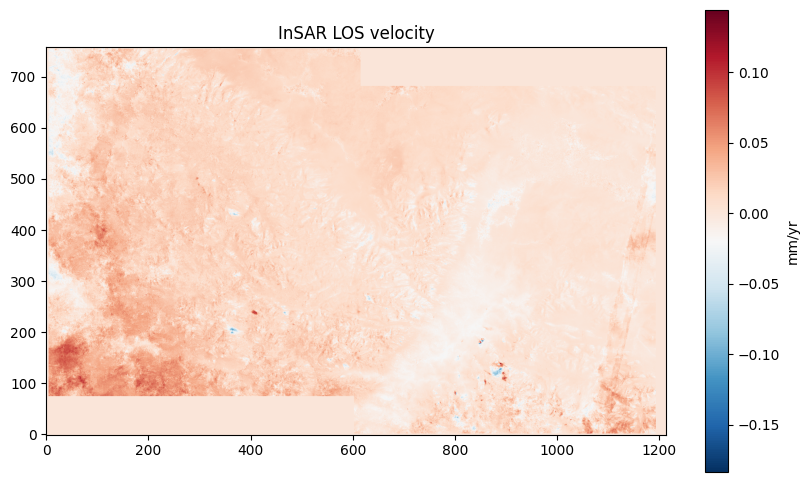

In [4]:
# Cell 2 - Load InSAR velocity data
h5_path = '/Volumes/AbeMBeats/new_data_asif/velocity.h5'
with h5py.File(h5_path, 'r') as f:
    print('Keys:', list(f.keys()))
    vel = f['velocity'][:]

test_image = vel[0].astype(np.float32) if vel.ndim == 3 else vel.astype(np.float32)
test_image = np.nan_to_num(test_image, nan=0.0)
image = test_image  # use same variable name as ASTER notebook

print(f'InSAR velocity: {image.shape}, range [{image.min():.3f}, {image.max():.3f}]')
plt.figure(figsize=(10, 6))
plt.imshow(image[::4, ::4], origin='lower', cmap='RdBu_r', rasterized=True)
plt.colorbar(label='mm/yr')
plt.title('InSAR LOS velocity')
plt.show()

In [5]:
# Cell 4 - CWT functions with scale-dependent padding + normalization option

def compute_scales(n_octaves, n_voices, a_min=1.0):
    scales = []
    norm_factor = 6.0 / 0.86
    for oct in range(n_octaves):
        for vox in range(n_voices):
            s = a_min * (2.0 ** (oct + vox / n_voices)) * norm_factor
            scales.append(s)
    return np.array(scales)

def gaussian_derivative_wavelet_2d(kx_grid, ky_grid, scale):
    """Gaussian derivative wavelets (1 vanishing moment).
    Freq grid has no 2*pi. NO x↔y swap (numpy/MLX convention).
    psi_x = i*kx*exp(-k²) = column derivative
    psi_y = i*ky*exp(-k²) = row derivative
    """
    akx = kx_grid
    aky = ky_grid
    gauss = mx.exp(-(akx * akx + aky * aky))
    psi_x = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                np.array(akx * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)
    psi_y = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                np.array(aky * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)
    return psi_x, psi_y

def mexican_derivative_wavelet_2d(kx_grid, ky_grid, scale):
    """Mexican hat derivative wavelets matching xsmurf convention.
    
    Same as Gaussian but with extra (kx²+ky²) factor → 3 vanishing moments.
    """
    akx = kx_grid
    aky = ky_grid
    gauss = mx.exp(-(akx * akx + aky * aky))
    k2 = akx * akx + aky * aky
    
    psi_x = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                np.array(akx * k2 * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)
    psi_y = mx.array(np.stack([np.zeros_like(np.array(gauss)),
                                np.array(aky * k2 * gauss)], axis=-1)).view(mx.complex64).squeeze(-1)
    return psi_x, psi_y

def cwt_2d_adaptive_pad(image, scales, min_pad=32, pad_factor=2.0, 
                         norm=False, wavelet='mexican', verbose=True):
    """2D CWT with scale-dependent mirror padding.
    
    Frequency grid matches xsmurf: kx = i*scale/N (no 2*pi factor).
    NO x↔y swap needed (numpy/MLX FFT is standard).
    
    norm: False (xsmurf default), 'L1' (a^-2), 'L2' (a^-1)
    wavelet: 'gaussian' (1 vanishing moment) or 'mexican' (3 vanishing moments)
    """
    ny, nx = image.shape
    n_scales = len(scales)
    modulus = np.zeros((n_scales, ny, nx), dtype=np.float32)
    argument = np.zeros((n_scales, ny, nx), dtype=np.float32)
    
    for i, scale in enumerate(scales):
        pad_w = max(min_pad, int(np.ceil(pad_factor * scale)))
        
        padded = np.pad(image, pad_w, mode='reflect')
        ny_p, nx_p = padded.shape
        crop = (slice(pad_w, pad_w + ny), slice(pad_w, pad_w + nx))
        
        # Frequency grid matching xsmurf: k = i/N (no 2*pi!)
        # Then scaled: ak = i*scale/N
        kx_np = fftfreq(nx_p)  # [0, 1/N, 2/N, ..., -1/N] — no 2*pi
        ky_np = fftfreq(ny_p)
        KX_np, KY_np = np.meshgrid(kx_np, ky_np)
        # Apply scale here (matching xsmurf: kx = i*scale/N)
        KX = mx.array((KX_np * scale).astype(np.float32))
        KY = mx.array((KY_np * scale).astype(np.float32))
        
        image_fft = mx.fft.fft2(mx.array(padded.astype(np.float32)))
        
        if wavelet == 'gaussian':
            psi_x, psi_y = gaussian_derivative_wavelet_2d(KX, KY, scale)
        elif wavelet == 'mexican':
            psi_x, psi_y = mexican_derivative_wavelet_2d(KX, KY, scale)
        else:
            raise ValueError(f"Unknown wavelet: {wavelet}")
        
        wx = mx.fft.ifft2(image_fft * psi_x)
        wy = mx.fft.ifft2(image_fft * psi_y)
        mx.eval(wx, wy)
        
        wx_np = np.array(wx.real)[crop]
        wy_np = np.array(wy.real)[crop]
        
        # Apply normalization
        if norm == 'L1':
            wx_np /= (scale * scale)
            wy_np /= (scale * scale)
        elif norm == 'L2':
            wx_np /= scale
            wy_np /= scale
        
        modulus[i] = np.sqrt(wx_np**2 + wy_np**2)
        argument[i] = np.arctan2(wy_np, wx_np)
        
        if verbose:
            print(f'  Scale {i}: a={scale:.1f}, pad={pad_w}, '
                  f'FFT={ny_p}x{nx_p}', flush=True)
    
    return modulus, argument

print(f'CWT functions defined (xsmurf-matched freq grid, no 2pi, NO x↔y swap (standard FFT convention))')

CWT functions defined (xsmurf-matched freq grid, no 2pi, NO x↔y swap (standard FFT convention))


In [6]:
# Cell 5a - Compute CWT using MLX GPU (adaptive padding)
# InSAR velocity — single image, not multi-band
print(f'Processing InSAR velocity: {image.shape}')

n_oct = 5    # octaves
n_vox = 8   # voices per octave
CWT_NORM =False      # False (xsmurf default), 'L1' (a^-2), 'L2' (a^-1)
WAVELET = 'mexican'   # 'gaussian' (1 vanishing moment) or 'mexican' (3 vanishing moments)

scales = compute_scales(n_oct, n_vox, a_min=1.0)
print(f'{len(scales)} scales: [{scales[0]:.1f}, {scales[-1]:.1f}]')
print(f'Wavelet: {WAVELET}, norm: {CWT_NORM}')

modulus, argument = cwt_2d_adaptive_pad(image, scales, min_pad=32, pad_factor=2.0,
                                         norm=CWT_NORM, wavelet=WAVELET)
print(f'\nDone: modulus shape = {modulus.shape}')

print('\n>>> Run Cell 5a (MLX) OR Cell 5b (xsmurf gfft) — not both')

Processing InSAR velocity: (3029, 4855)
40 scales: [7.0, 204.7]
Wavelet: mexican, norm: False
  Scale 0: a=7.0, pad=32, FFT=3093x4919
  Scale 1: a=7.6, pad=32, FFT=3093x4919
  Scale 2: a=8.3, pad=32, FFT=3093x4919
  Scale 3: a=9.0, pad=32, FFT=3093x4919
  Scale 4: a=9.9, pad=32, FFT=3093x4919
  Scale 5: a=10.8, pad=32, FFT=3093x4919
  Scale 6: a=11.7, pad=32, FFT=3093x4919
  Scale 7: a=12.8, pad=32, FFT=3093x4919
  Scale 8: a=14.0, pad=32, FFT=3093x4919
  Scale 9: a=15.2, pad=32, FFT=3093x4919
  Scale 10: a=16.6, pad=34, FFT=3097x4923
  Scale 11: a=18.1, pad=37, FFT=3103x4929
  Scale 12: a=19.7, pad=40, FFT=3109x4935
  Scale 13: a=21.5, pad=44, FFT=3117x4943
  Scale 14: a=23.5, pad=47, FFT=3123x4949
  Scale 15: a=25.6, pad=52, FFT=3133x4959
  Scale 16: a=27.9, pad=56, FFT=3141x4967
  Scale 17: a=30.4, pad=61, FFT=3151x4977
  Scale 18: a=33.2, pad=67, FFT=3163x4989
  Scale 19: a=36.2, pad=73, FFT=3175x5001
  Scale 20: a=39.5, pad=79, FFT=3187x5013
  Scale 21: a=43.0, pad=87, FFT=3203x50

In [8]:
# Cell 5b - Compute CWT using xsmurf native gfft + libmatheval (power-of-2 required)
# Alternative to Cell 5a. Pad image to power-of-2 for gfft.
import math

n_oct = 7
n_vox = 2
scales = compute_scales(n_oct, n_vox, a_min=1.0)

# Pad to power of 2
ny, nx = image.shape
new_nx = int(2 ** math.ceil(math.log2(nx)))
new_ny = int(2 ** math.ceil(math.log2(ny)))
padded = np.pad(image, ((0, new_ny - ny), (0, new_nx - nx)), mode='reflect').astype(np.float32)
print(f'Padded: {image.shape} -> {padded.shape}')

# xsmurf gfft
img_xsm = xsm.XImage.from_numpy(padded)
fft_xsm = xsm.igfft(img_xsm)
print('gfft done')

# Gaussian derivative expressions (gfft convention: x=col, y=row, NO swap)
WAVELET_EXPRS = {
    'gaussian': {'dx': ('0', 'x*exp(-x*x-y*y)'), 'dy': ('0', 'y*exp(-x*x-y*y)')},
    'mexican':  {'dx': ('0', 'x*(x*x+y*y)*exp(-x*x-y*y)'), 'dy': ('0', 'y*(x*x+y*y)*exp(-x*x-y*y)')},
}
WAVELET = 'gaussian'  # or 'mexican'
dx_expr = WAVELET_EXPRS[WAVELET]['dx']
dy_expr = WAVELET_EXPRS[WAVELET]['dy']
print(f'Wavelet: {WAVELET}')

modulus = np.zeros((len(scales), ny, nx), dtype=np.float32)
argument = np.zeros((len(scales), ny, nx), dtype=np.float32)

for i, scale in enumerate(scales):
    # iconvol duplicates internally, convolves via libmatheval
    dx_img = xsm.igifft(xsm.iconvol(fft_xsm, dx_expr[0], dx_expr[1], scale))
    dy_img = xsm.igifft(xsm.iconvol(fft_xsm, dy_expr[0], dy_expr[1], scale))
    mod_img = xsm.gmod(dx_img, dy_img)
    arg_img = xsm.garg(dx_img, dy_img)
    
    # Crop back to original size
    modulus[i] = mod_img.to_numpy()[:ny, :nx]
    argument[i] = arg_img.to_numpy()[:ny, :nx]
    
    if i % 10 == 0 or i == len(scales) - 1:
        print(f'  Scale {i}: a={scale:.1f}, mod range [{modulus[i].min():.4f}, {modulus[i].max():.4f}]')

print(f'\nDone: {len(scales)} scales, modulus shape = {modulus.shape}')
print(f'Method: xsmurf gfft + libmatheval ({WAVELET})')
print('\n>>> Run Cell 5a (MLX) OR Cell 5b (xsmurf gfft) — not both')

Padded: (3029, 4855) -> (4096, 8192)
gfft done
Wavelet: gaussian
  Scale 0: a=7.0, mod range [0.0000, 0.0388]
  Scale 10: a=223.3, mod range [0.0000, 0.0165]
  Scale 13: a=631.5, mod range [0.0000, 0.0138]

Done: 14 scales, modulus shape = (14, 3029, 4855)
Method: xsmurf gfft + libmatheval (gaussian)

>>> Run Cell 5a (MLX) OR Cell 5b (xsmurf gfft) — not both


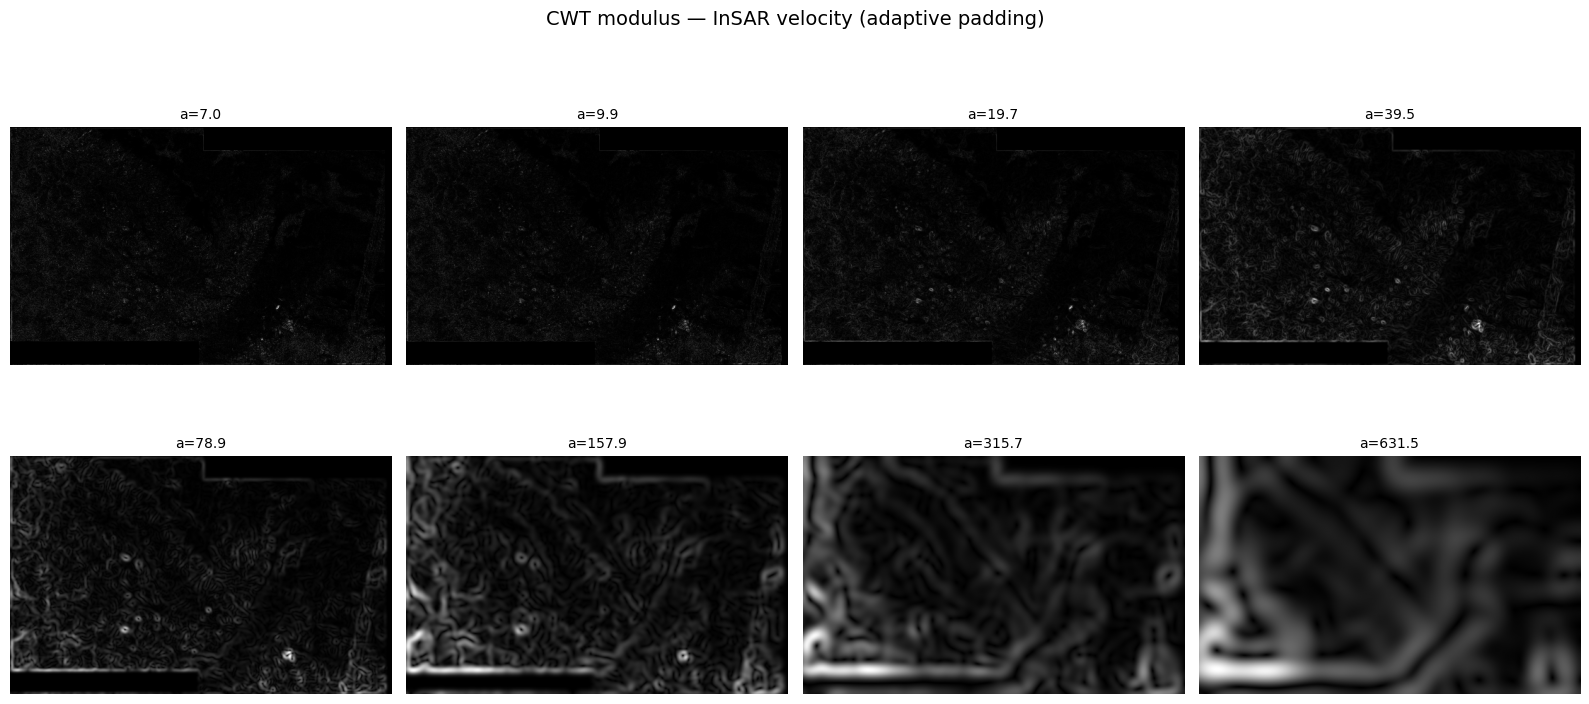

In [9]:
# Cell 6 - Scalogram preview
ds = max(1, max(image.shape) // 500)
n_show = min(8, len(scales))
indices = np.linspace(0, len(scales)-1, n_show, dtype=int)

fig, axes = plt.subplots(2, n_show//2, figsize=(4*n_show//2, 8))
for ax, idx in zip(axes.flat, indices):
    ax.imshow(modulus[idx][::ds, ::ds], origin='lower', cmap='binary_r', rasterized=True)
    ax.set_title(f'a={scales[idx]:.1f}', fontsize=10)
    ax.axis('off')
plt.suptitle(f'CWT modulus — InSAR velocity (adaptive padding)', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# Cell 7 - Interactive crop selection
from ipywidgets import interact, IntRangeSlider, Layout

ly, lx = image.shape
ds_c = max(1, max(ly, lx) // 500)
mid = len(scales) -1
img_preview = image[::ds_c, ::ds_c]

def show_crop(y_range, x_range):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(img_preview, origin='lower', cmap='gray', rasterized=True)
    rect = plt.Rectangle((x_range[0]//ds_c, y_range[0]//ds_c),
                          (x_range[1]-x_range[0])//ds_c,
                          (y_range[1]-y_range[0])//ds_c,
                          linewidth=2, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f'{'InSAR'} — green = crop')
    crop_mod = modulus[mid, y_range[0]:y_range[1]:ds_c, x_range[0]:x_range[1]:ds_c]
    axes[1].imshow(crop_mod, origin='lower', cmap='hot', rasterized=True)
    axes[1].set_title(f'|W| at scale {scales[mid]:.1f}')
    plt.suptitle(f'Crop: {y_range[1]-y_range[0]} x {x_range[1]-x_range[0]}')
    plt.tight_layout()
    plt.show()

interact(show_crop,
         y_range=IntRangeSlider(value=[100, ly-100], min=0, max=ly, step=16,
                                description='Y:', layout=Layout(width='80%')),
         x_range=IntRangeSlider(value=[100, lx-100], min=0, max=lx, step=16,
                                description='X:', layout=Layout(width='80%')))

interactive(children=(IntRangeSlider(value=(100, 2929), description='Y:', layout=Layout(width='80%'), max=3029…

<function __main__.show_crop(y_range, x_range)>

In [ ]:
y0, y1 = 16, 2576   # <-- adjust from sliders
x0, x1 = 2448, 4736   # <-- adjust from sliders                                                                         

crop_image = image[y0:y1, x0:x1]                                                                                       
crop_mod = modulus[:, y0:y1, x0:x1].copy()                          
crop_arg = argument[:, y0:y1, x0:x1].copy()                                                                            
print(f'Cropped: {crop_image.shape}')
                                                                                                                        
USE_NMAXSUP = True  # True = wtmm2d (xsmurf default), False = find_extrema                                             

ext_images = []                                                                                                        
for i, scale in enumerate(scales):                                  
    if USE_NMAXSUP:
        # wtmm2d needs raw dx, dy — reconstruct from mod and arg
        dx = crop_mod[i] * np.cos(crop_arg[i])                                                                         
        dy = crop_mod[i] * np.sin(crop_arg[i])                                                                         
        dx_img = xsm.XImage.from_numpy(dx)                                                                             
        dy_img = xsm.XImage.from_numpy(dy)                                                                             
        ext, _, _ = xsm.wtmm2d(dx_img, dy_img, scale, thresh=0.00001) 
    else:                                                                                                              
        mod_img = xsm.XImage.from_numpy(crop_mod[i])                                                                   
        arg_img = xsm.XImage.from_numpy(crop_arg[i])
        ext = xsm.find_extrema(mod_img, arg_img, scale, thresh=0.00001)                                                  
    ext_images.append(ext)                                                                                             
    print(f'  Scale {i}: a={scale:.1f}, {ext.extr_nb} extrema')
                                                                                                                        
print(f'\nTotal: {sum(e.extr_nb for e in ext_images)} extrema')         

Cropped: (2560, 2288)
  Scale 0: a=7.0, 1315184 extrema
  Scale 1: a=9.9, 941596 extrema
  Scale 2: a=14.0, 664184 extrema
  Scale 3: a=19.7, 470879 extrema
  Scale 4: a=27.9, 334197 extrema
  Scale 5: a=39.5, 239787 extrema
  Scale 6: a=55.8, 174383 extrema
  Scale 7: a=78.9, 127839 extrema
  Scale 8: a=111.6, 91376 extrema
  Scale 9: a=157.9, 66447 extrema
  Scale 10: a=223.3, 46679 extrema
  Scale 11: a=315.7, 32495 extrema
  Scale 12: a=446.5, 22083 extrema
  Scale 13: a=631.5, 15579 extrema

Total: 4542708 extrema


  Octave 0 - voice 0 - scale 6.9767 (0)
  Octave 0 - voice 1 - scale 9.8666 (1)
  Octave 1 - voice 0 - scale 13.9535 (2)
  Octave 1 - voice 1 - scale 19.7332 (3)
  Octave 2 - voice 0 - scale 27.9070 (4)
  Octave 2 - voice 1 - scale 39.4664 (5)
  Octave 3 - voice 0 - scale 55.8140 (6)
  Octave 3 - voice 1 - scale 78.9328 (7)
  Octave 4 - voice 0 - scale 111.6279 (8)
  Octave 4 - voice 1 - scale 157.8657 (9)
  Octave 5 - voice 0 - scale 223.2558 (10)
  Octave 5 - voice 1 - scale 315.7314 (11)
  Octave 6 - voice 0 - scale 446.5116 (12)
  Octave 6 - voice 1 - scale 631.4628 (13)
58536 vertical chains


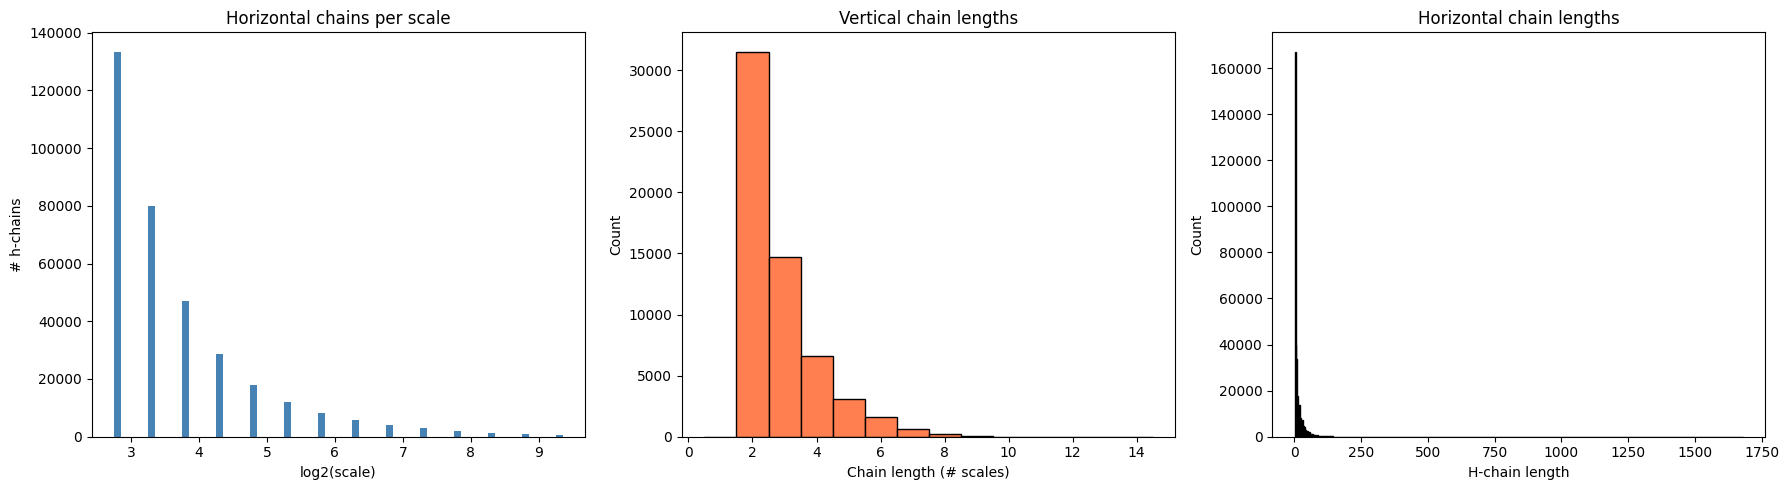

In [ ]:
# Cell 9 - Chain
xsm.chain(ext_images, a_min=1.0, n_oct=n_oct, n_vox=n_vox)
chains = xsm.extract_vertical_chains(ext_images, scales)
print(f'{len(chains)} vertical chains')

# Chain statistics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Horizontal chains per scale
n_lines = [ext.nb_of_lines for ext in ext_images]
axes[0].bar(np.log2(scales), n_lines, width=0.1, color='steelblue')
axes[0].set(xlabel='log2(scale)', ylabel='# h-chains', title='Horizontal chains per scale')

# Vertical chain lengths
vc_lens = [len(ch['mod']) for ch in chains]
axes[1].hist(vc_lens, bins=np.arange(0.5, len(scales)+1.5, 1), color='coral', edgecolor='k')
axes[1].set(xlabel='Chain length (# scales)', ylabel='Count', title='Vertical chain lengths')

# H-chain length distribution
all_hlen = []
for ext in ext_images:
    for line in ext.get_lines():
        all_hlen.append(line['size'])
if all_hlen:
    axes[2].hist(all_hlen, bins=500, color='mediumpurple', edgecolor='k')
axes[2].set(xlabel='H-chain length', ylabel='Count', title='Horizontal chain lengths')

plt.tight_layout()
plt.show()

LS fit:    mean=-0.148, std=0.283
Max slope: mean=-0.069, std=0.319


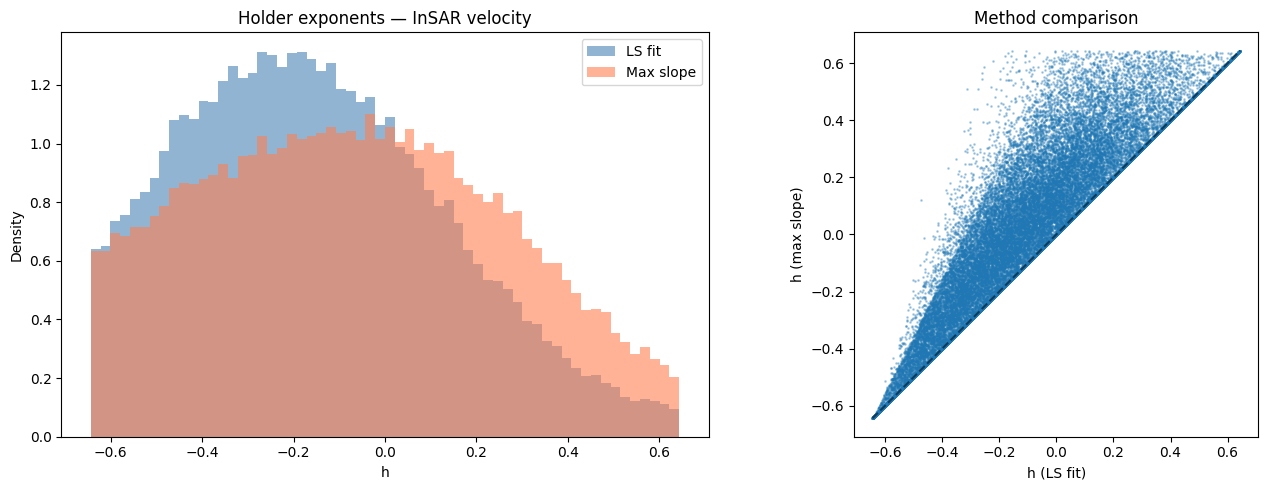

In [ ]:
# Cell 10 - Holder exponents
holders_fit = xsm.compute_holder_exponents(chains)
holders_slope = xsm.compute_holder_local_slope(chains, method='max')
h_fit = np.array([h['h'] for h in holders_fit])
h_slope = np.array([h['h'] for h in holders_slope])

print(f'LS fit:    mean={h_fit.mean():.3f}, std={h_fit.std():.3f}')
print(f'Max slope: mean={h_slope.mean():.3f}, std={h_slope.std():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(h_fit, bins=60, alpha=0.6, color='steelblue', label='LS fit', density=True)
axes[0].hist(h_slope, bins=60, alpha=0.6, color='coral', label='Max slope', density=True)
axes[0].set(xlabel='h', ylabel='Density', title=f'Holder exponents — InSAR velocity')
axes[0].legend()

axes[1].scatter(h_fit, h_slope, s=1, alpha=0.3, rasterized=True)
lims = [min(h_fit.min(), h_slope.min()), max(h_fit.max(), h_slope.max())]
axes[1].plot(lims, lims, 'k--', alpha=0.5)
axes[1].set(xlabel='h (LS fit)', ylabel='h (max slope)', title='Method comparison')
axes[1].set_aspect('equal')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 9b - Precompute flat arrays for fast interactive viewer (fast version)
import time
import numpy as np

t0 = time.time()

h_fit_lookup = {(int(hd['x']), int(hd['y'])): hd['h'] for hd in holders_fit}
h_slope_lookup = {(int(hd['x']), int(hd['y'])): hd['h'] for hd in holders_slope}

# ------------------------------------------------------------------
# Build one global lookup:
#   (si, x, y) -> {'vc_len': ..., 'anchor_key': (x0, y0)}
# ------------------------------------------------------------------
chain_lookup = {}
for ch in chains:
    vc_len = len(ch['mod'])
    if vc_len == 0:
        continue

    anchor_key = (int(ch['x'][0]), int(ch['y'][0]))

    n_sc = min(vc_len, len(scales))
    for si in range(n_sc):
        key = (si, int(ch['x'][si]), int(ch['y'][si]))
        chain_lookup[key] = (vc_len, anchor_key)

print(f"Built chain lookup with {len(chain_lookup)} entries in {time.time()-t0:.1f}s")

all_xs, all_ys, all_args, all_mods = [], [], [], []
all_scale_idx, all_hchain_len = [], []
all_line_h_fit, all_line_h_slope = [], []
all_line_max_vc, all_point_vc = [], []

for si in range(len(scales)):
    ext = ext_images[si]
    lines = ext.get_lines()
    data = ext.get_extrema_arrays()
    lx_ext = ext.lx

    pos = data['pos'].astype(np.int64)
    xs_all = data['x'].astype(np.int32)
    ys_all = data['y'].astype(np.int32)
    args_all = data['arg'].astype(np.float32)
    mods_all = data['mod'].astype(np.float32)

    pos_to_arg = dict(zip(pos, args_all))
    pos_to_mod = dict(zip(pos, mods_all))

    # Build pos -> vc length directly from precomputed chain_lookup
    pos_to_vc = {}
    on_vc = ext.get_on_vertical_chain()

    for j_ext in range(ext.extr_nb):
        p = int(pos[j_ext])
        if on_vc[j_ext]:
            key = (si, int(xs_all[j_ext]), int(ys_all[j_ext]))
            vc_len = chain_lookup.get(key, (0, None))[0]
        else:
            vc_len = 0
        pos_to_vc[p] = vc_len

    for line in lines:
        positions = np.asarray(line['extrema_pos'], dtype=np.int64)

        xs = (positions % lx_ext).astype(np.int32)
        ys = (positions // lx_ext).astype(np.int32)
        args = np.array([pos_to_arg.get(int(p), 0.0) for p in positions], dtype=np.float32)
        mods = np.array([pos_to_mod.get(int(p), 0.0) for p in positions], dtype=np.float32)
        point_vcs = np.array([pos_to_vc.get(int(p), 0) for p in positions], dtype=np.int32)

        n_pts = len(xs)
        line_max_vc = int(point_vcs.max()) if n_pts > 0 else 0

        line_h_fit = np.nan
        line_h_slope = np.nan

        if line_max_vc > 0:
            best_idx = int(np.argmax(point_vcs))
            px, py = int(xs[best_idx]), int(ys[best_idx])

            vc_len, anchor_key = chain_lookup.get((si, px, py), (0, None))
            if anchor_key is not None:
                line_h_fit = h_fit_lookup.get(anchor_key, np.nan)
                line_h_slope = h_slope_lookup.get(anchor_key, np.nan)

        all_xs.append(xs)
        all_ys.append(ys)
        all_args.append(args)
        all_mods.append(mods)
        all_scale_idx.append(np.full(n_pts, si, dtype=np.int32))
        all_hchain_len.append(np.full(n_pts, line['size'], dtype=np.int32))
        all_line_h_fit.append(np.full(n_pts, line_h_fit, dtype=np.float32))
        all_line_h_slope.append(np.full(n_pts, line_h_slope, dtype=np.float32))
        all_line_max_vc.append(np.full(n_pts, line_max_vc, dtype=np.int32))
        all_point_vc.append(point_vcs)

flat_x = np.concatenate(all_xs) if all_xs else np.array([], dtype=np.int32)
flat_y = np.concatenate(all_ys) if all_ys else np.array([], dtype=np.int32)
flat_arg = np.concatenate(all_args) if all_args else np.array([], dtype=np.float32)
flat_mod = np.concatenate(all_mods) if all_mods else np.array([], dtype=np.float32)
flat_si = np.concatenate(all_scale_idx) if all_scale_idx else np.array([], dtype=np.int32)
flat_hlen = np.concatenate(all_hchain_len) if all_hchain_len else np.array([], dtype=np.int32)
flat_h_fit = np.concatenate(all_line_h_fit) if all_line_h_fit else np.array([], dtype=np.float32)
flat_h_slope = np.concatenate(all_line_h_slope) if all_line_h_slope else np.array([], dtype=np.float32)
flat_line_max_vc = np.concatenate(all_line_max_vc) if all_line_max_vc else np.array([], dtype=np.int32)
flat_point_vc = np.concatenate(all_point_vc) if all_point_vc else np.array([], dtype=np.int32)

print(f"Precomputed {len(flat_x)} points from {len(all_xs)} lines in {time.time()-t0:.1f}s")
print(f"  {(flat_line_max_vc > 0).sum()} points on lines with vc anchors")

Built chain lookup with 166026 entries in 0.3s
Precomputed 4542708 points from 345076 lines in 15.2s
  2990664 points on lines with vc anchors


In [ ]:
# Cell 9c - Faster interactive extrema viewer
from ipywidgets import interact, IntSlider, Checkbox, Dropdown, FloatSlider, Layout
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Precompute background images
# -----------------------------
crop_f = crop_image.astype(np.float64)
crop_lin = crop_f.copy()
crop_log = np.log1p(crop_f - crop_f.min())

def hist_eq(img):
    flat = img.ravel()
    hist, bins = np.histogram(flat[np.isfinite(flat)], bins=1000)
    cdf = hist.cumsum().astype(np.float64)
    cdf = cdf / cdf[-1]
    out = np.interp(flat, bins[:-1], cdf).reshape(img.shape)
    return out

crop_heq = hist_eq(crop_f)
stretch_dict = {'Linear': crop_lin, 'Log': crop_log, 'Histogram EQ': crop_heq}

# Downsample for speed
ds_bg = max(1, max(crop_image.shape) // 800)

# -----------------------------
# Precompute lookups used in callback
# -----------------------------
scale_masks = [(flat_si == si) for si in range(len(scales))]

vc_x_arr = np.array([int(ch['x'][0]) for ch in chains], dtype=np.int32)
vc_y_arr = np.array([int(ch['y'][0]) for ch in chains], dtype=np.int32)
vc_len_arr = np.array([len(ch['mod']) for ch in chains], dtype=np.int32)
vc_h_fit_arr = np.array(
    [h_fit_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan) for ch in chains],
    dtype=np.float32
)
vc_h_slope_arr = np.array(
    [h_slope_lookup.get((int(ch['x'][0]), int(ch['y'][0])), np.nan) for ch in chains],
    dtype=np.float32
)

def robust_limits(vals, lo=5, hi=95, default=(-1, 1)):
    if len(vals) == 0:
        return default
    return np.percentile(vals, lo), np.percentile(vals, hi)

def downsample_points(x, y, c, max_plot=120000):
    n = len(x)
    if n <= max_plot:
        return x, y, c
    step = int(np.ceil(n / max_plot))
    return x[::step], y[::step], c[::step]

def draw_fast(scale_idx, single_scale, min_hchain, min_vc, min_h, h_filter_method,
              color_by, cmap_name, show_mode, stretch, show_bg):

    fig, ax = plt.subplots(figsize=(14, 10))

    if show_bg:
        bg = stretch_dict[stretch]
        ax.imshow(bg[::ds_bg, ::ds_bg], origin='lower', cmap='gray',
                  rasterized=True,
                  extent=[0, crop_image.shape[1], 0, crop_image.shape[0]],
                  alpha=0.6)
        ax.set_facecolor('black')
    else:
        ax.set_facecolor('white')

    if show_mode == 'Horizontal chains':
        mask = (flat_hlen >= min_hchain)

        if single_scale:
            mask &= scale_masks[scale_idx]

        if min_vc > 0:
            mask &= (flat_line_max_vc >= min_vc)

        if min_h > -4.9 and color_by in ('h (LS fit)', 'h (max slope)'):
            h_ref = flat_h_fit if h_filter_method == 'LS fit' else flat_h_slope
            mask &= (h_ref >= min_h) | np.isnan(h_ref)

        x_m = flat_x[mask]
        y_m = flat_y[mask]

        if color_by == 'h (LS fit)':
            c_vals = flat_h_fit[mask]
            valid = ~np.isnan(c_vals)
            x_m, y_m, c_vals = x_m[valid], y_m[valid], c_vals[valid]
            vmin, vmax = robust_limits(c_vals, 5, 95)
            clabel = 'h (LS fit)'

        elif color_by == 'h (max slope)':
            c_vals = flat_h_slope[mask]
            valid = ~np.isnan(c_vals)
            x_m, y_m, c_vals = x_m[valid], y_m[valid], c_vals[valid]
            vmin, vmax = robust_limits(c_vals, 5, 95)
            clabel = 'h (max slope)'

        elif color_by == 'argument':
            c_vals = flat_arg[mask]
            vmin, vmax = -np.pi, np.pi
            cmap_name = 'hsv'
            clabel = 'arg(W) [rad]'

        elif color_by == 'modulus':
            c_vals = np.log2(np.maximum(np.abs(flat_mod[mask]), 1e-30))
            vmin, vmax = robust_limits(c_vals, 2, 98, default=(-10, 0))
            clabel = 'log2(|W|)'

        x_m, y_m, c_vals = downsample_points(x_m, y_m, c_vals, max_plot=120000)

        if len(x_m) > 0:
            sc = ax.scatter(x_m, y_m, c=c_vals, s=0.2, cmap=cmap_name,
                            vmin=vmin, vmax=vmax, rasterized=True)
            cb = plt.colorbar(sc, ax=ax, label=clabel, shrink=0.6)
            if color_by == 'argument':
                cb.set_ticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
                cb.set_ticklabels(['-π', '-π/2', '0', 'π/2', 'π'])

        n_pts = len(x_m)

    else:
        vc_mask = (vc_len_arr >= max(min_vc, 2))

        if min_h > -4.9:
            h_ref = vc_h_fit_arr if h_filter_method == 'LS fit' else vc_h_slope_arr
            vc_mask &= (h_ref >= min_h) | np.isnan(h_ref)

        if color_by == 'h (LS fit)':
            c_raw = vc_h_fit_arr
        else:
            c_raw = vc_h_slope_arr

        c_vals = c_raw[vc_mask]
        valid = ~np.isnan(c_vals)

        x_m = vc_x_arr[vc_mask][valid]
        y_m = vc_y_arr[vc_mask][valid]
        c_vals = c_vals[valid]

        vmin, vmax = robust_limits(c_vals, 5, 95)
        x_m, y_m, c_vals = downsample_points(x_m, y_m, c_vals, max_plot=50000)

        if len(x_m) > 0:
            sc = ax.scatter(x_m, y_m, c=c_vals, s=4, cmap=cmap_name,
                            vmin=vmin, vmax=vmax, rasterized=True)
            plt.colorbar(sc, ax=ax, label='h', shrink=0.6)

        n_pts = len(x_m)

    scope = f'scale {scale_idx} (a={scales[scale_idx]:.1f})' if single_scale else 'all scales'
    ax.set_title(f'{show_mode} | {color_by} — {n_pts} pts ({scope})')
    ax.set_xlim(0, crop_image.shape[1])
    ax.set_ylim(0, crop_image.shape[0])
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

interact(
    draw_fast,
    scale_idx=IntSlider(value=len(scales)//2, min=0, max=len(scales)-1,
                        description='Scale:', layout=Layout(width='60%'),
                        continuous_update=False),
    single_scale=Checkbox(value=True, description='Single scale only'),
    min_hchain=IntSlider(value=10, min=1, max=500, step=5,
                         description='Min h-chain:', layout=Layout(width='60%'),
                         continuous_update=False),
    min_vc=IntSlider(value=0, min=0, max=len(scales), step=1,
                     description='Min vc on line:', layout=Layout(width='60%'),
                     continuous_update=False),
    min_h=FloatSlider(value=-5.0, min=-5.0, max=5.0, step=0.1,
                      description='Min h:', layout=Layout(width='60%'),
                      continuous_update=False),
    h_filter_method=Dropdown(options=['Max slope', 'LS fit'], value='Max slope',
                             description='h filter on:'),
    color_by=Dropdown(options=['argument', 'h (LS fit)', 'h (max slope)', 'modulus'],
                      value='argument', description='Color by:'),
    cmap_name=Dropdown(options=['hsv', 'RdBu_r', 'coolwarm', 'seismic', 'PiYG',
                                'viridis', 'plasma', 'turbo', 'binary', 'binary_r'],
                       value='hsv', description='Colormap:'),
    show_mode=Dropdown(options=['Horizontal chains', 'VC origin points'],
                       value='Horizontal chains', description='Show:'),
    stretch=Dropdown(options=['Linear', 'Log', 'Histogram EQ'],
                     value='Linear', description='Stretch:'),
    show_bg=Checkbox(value=True, description='Show band image')
);

interactive(children=(IntSlider(value=7, continuous_update=False, description='Scale:', layout=Layout(width='6…

In [ ]:
# Cell 9d - Filter chains for partition function
# Set these based on what you see in the interactive viewer above.
# The partition function will only use vertical chains matching these criteria.

filt_min_vc = 1        # minimum vertical chain length (scales)
filt_min_hchain = 10   # minimum horizontal chain length
filt_min_h = -5     # minimum Holder exponent (set > -5 to filter)
filt_h_method = 'max_slope'  # 'ls_fit' or 'max_slope'

# Build filtered chain set
filtered_chains = []
for ch in chains:
    key = (int(ch['x'][0]), int(ch['y'][0]))
    vc_len = len(ch['mod'])
    
    # VC length filter
    if vc_len < filt_min_vc:
        continue
    
    # H filter
    if filt_min_h > -4.9:
        if filt_h_method == 'ls_fit':
            h_val = h_fit_lookup.get(key, np.nan)
        else:
            h_val = h_slope_lookup.get(key, np.nan)
        if np.isnan(h_val) or h_val < filt_min_h:
            continue
    
    filtered_chains.append(ch)

print(f"Filtered: {len(filtered_chains)} / {len(chains)} chains "
      f"(min_vc={filt_min_vc}, min_h={filt_min_h}, {filt_h_method})")

# Build a set of (scale_idx, x, y) positions that are on filtered chains
# so we can mask the partition function computation
filtered_positions = set()
for ch in filtered_chains:
    n_ch = len(ch['mod'])
    for si in range(min(n_ch, len(scales))):
        filtered_positions.add((si, int(ch['x'][si]), int(ch['y'][si])))

print(f"Total filtered vc points: {len(filtered_positions)}")

Filtered: 58536 / 58536 chains (min_vc=1, min_h=-5, max_slope)
Total filtered vc points: 166026


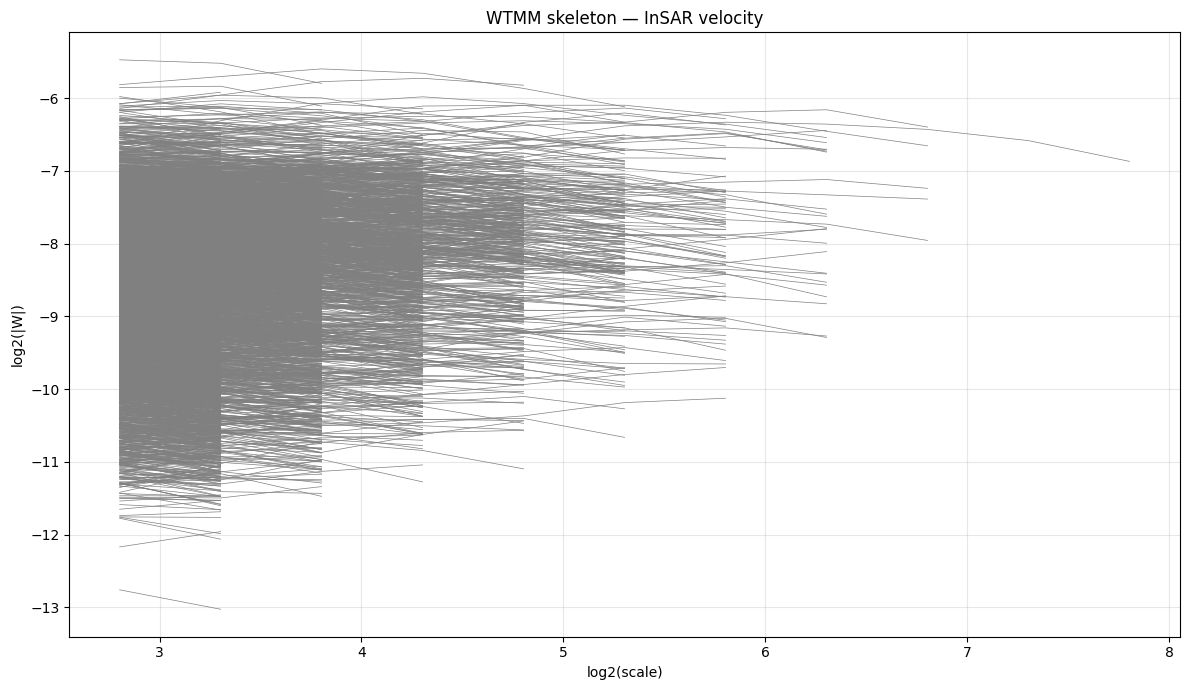

In [ ]:
# Cell 11 - Skeleton plot
fig, ax = plt.subplots(figsize=(12, 7))
log2_scales = np.log2(scales)

for ch in chains[:5000]:
    n = len(ch['mod'])
    if n < 2:
        continue
    log2_mod = np.log2(np.maximum(np.abs(ch['mod']), 1e-30))
    ax.plot(log2_scales[:n], log2_mod, '-', color='gray', alpha=1, lw=0.5)

ax.set(xlabel='log2(scale)', ylabel='log2(|W|)',
       title=f'WTMM skeleton — InSAR velocity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

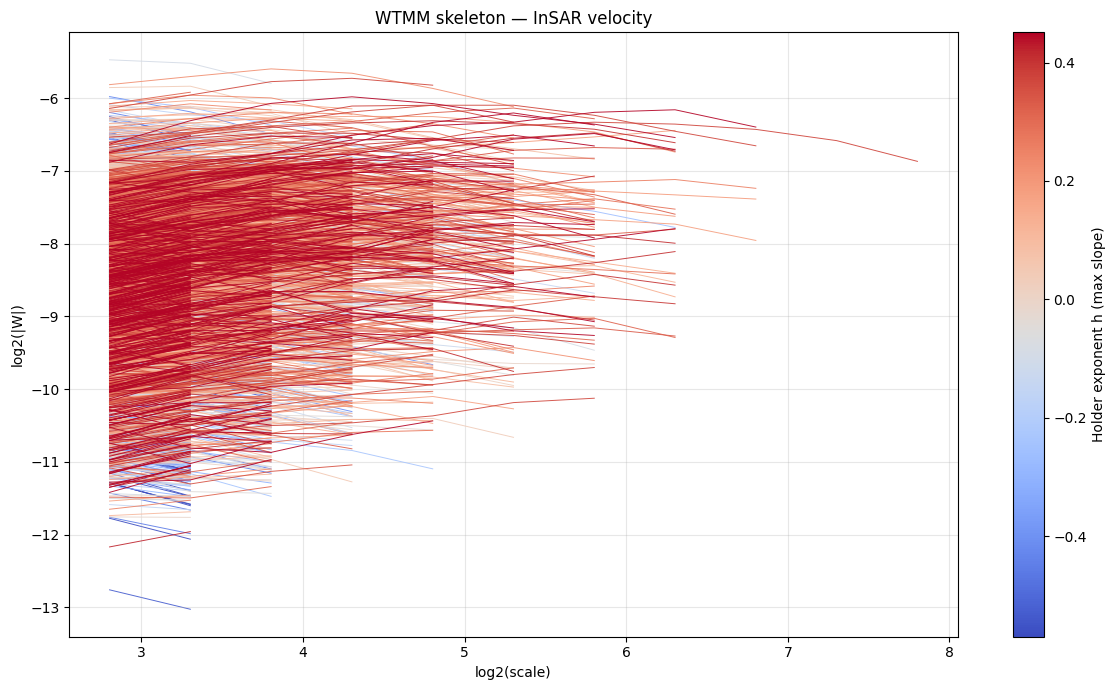

In [ ]:
# Cell 11 - Skeleton plot colored by max-slope Holder exponent
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(12, 7))
log2_scales = np.log2(scales)

# Lookup from anchor point -> h from earlier max-slope estimates
# Assumes holders_slope is a list of dicts like {'x':..., 'y':..., 'h':...}
h_slope_lookup = {
    (int(hd['x']), int(hd['y'])): float(hd['h'])
    for hd in holders_slope
}

# Collect plottable chains with their h values
plot_items = []
for ch in chains[:5000]:
    n = len(ch['mod'])
    if n < 2:
        continue

    key = (int(ch['x'][0]), int(ch['y'][0]))   # anchor point of chain
    h = h_slope_lookup.get(key, np.nan)
    if not np.isfinite(h):
        continue

    log2_mod = np.log2(np.maximum(np.abs(ch['mod']), 1e-30))
    plot_items.append((h, n, log2_mod))

# Nothing to plot guard
if len(plot_items) == 0:
    print("No chains with finite max-slope Holder exponents found.")
else:
    # Sort so lower h draws first, higher h draws last (on top)
    plot_items.sort(key=lambda t: t[0])

    h_vals = np.array([item[0] for item in plot_items], dtype=float)

    # Robust color limits
    vmin = np.percentile(h_vals, 5)
    vmax = np.percentile(h_vals, 95)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = np.nanmin(h_vals)
        vmax = np.nanmax(h_vals)

    norm = Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.coolwarm

    for h, n, log2_mod in plot_items:
        ax.plot(
            log2_scales[:n],
            log2_mod,
            '-',
            color=cmap(norm(h)),
            alpha=0.9,
            lw=0.7,
            zorder=2 + h  # larger h tends to go on top
        )

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label('Holder exponent h (max slope)')

ax.set(
    xlabel='log2(scale)',
    ylabel='log2(|W|)',
    title=f'WTMM skeleton — InSAR velocity'
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Partition functions computed with 58536 filtered chains
  Standard: extrema per scale = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Chainmax: extrema per scale = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


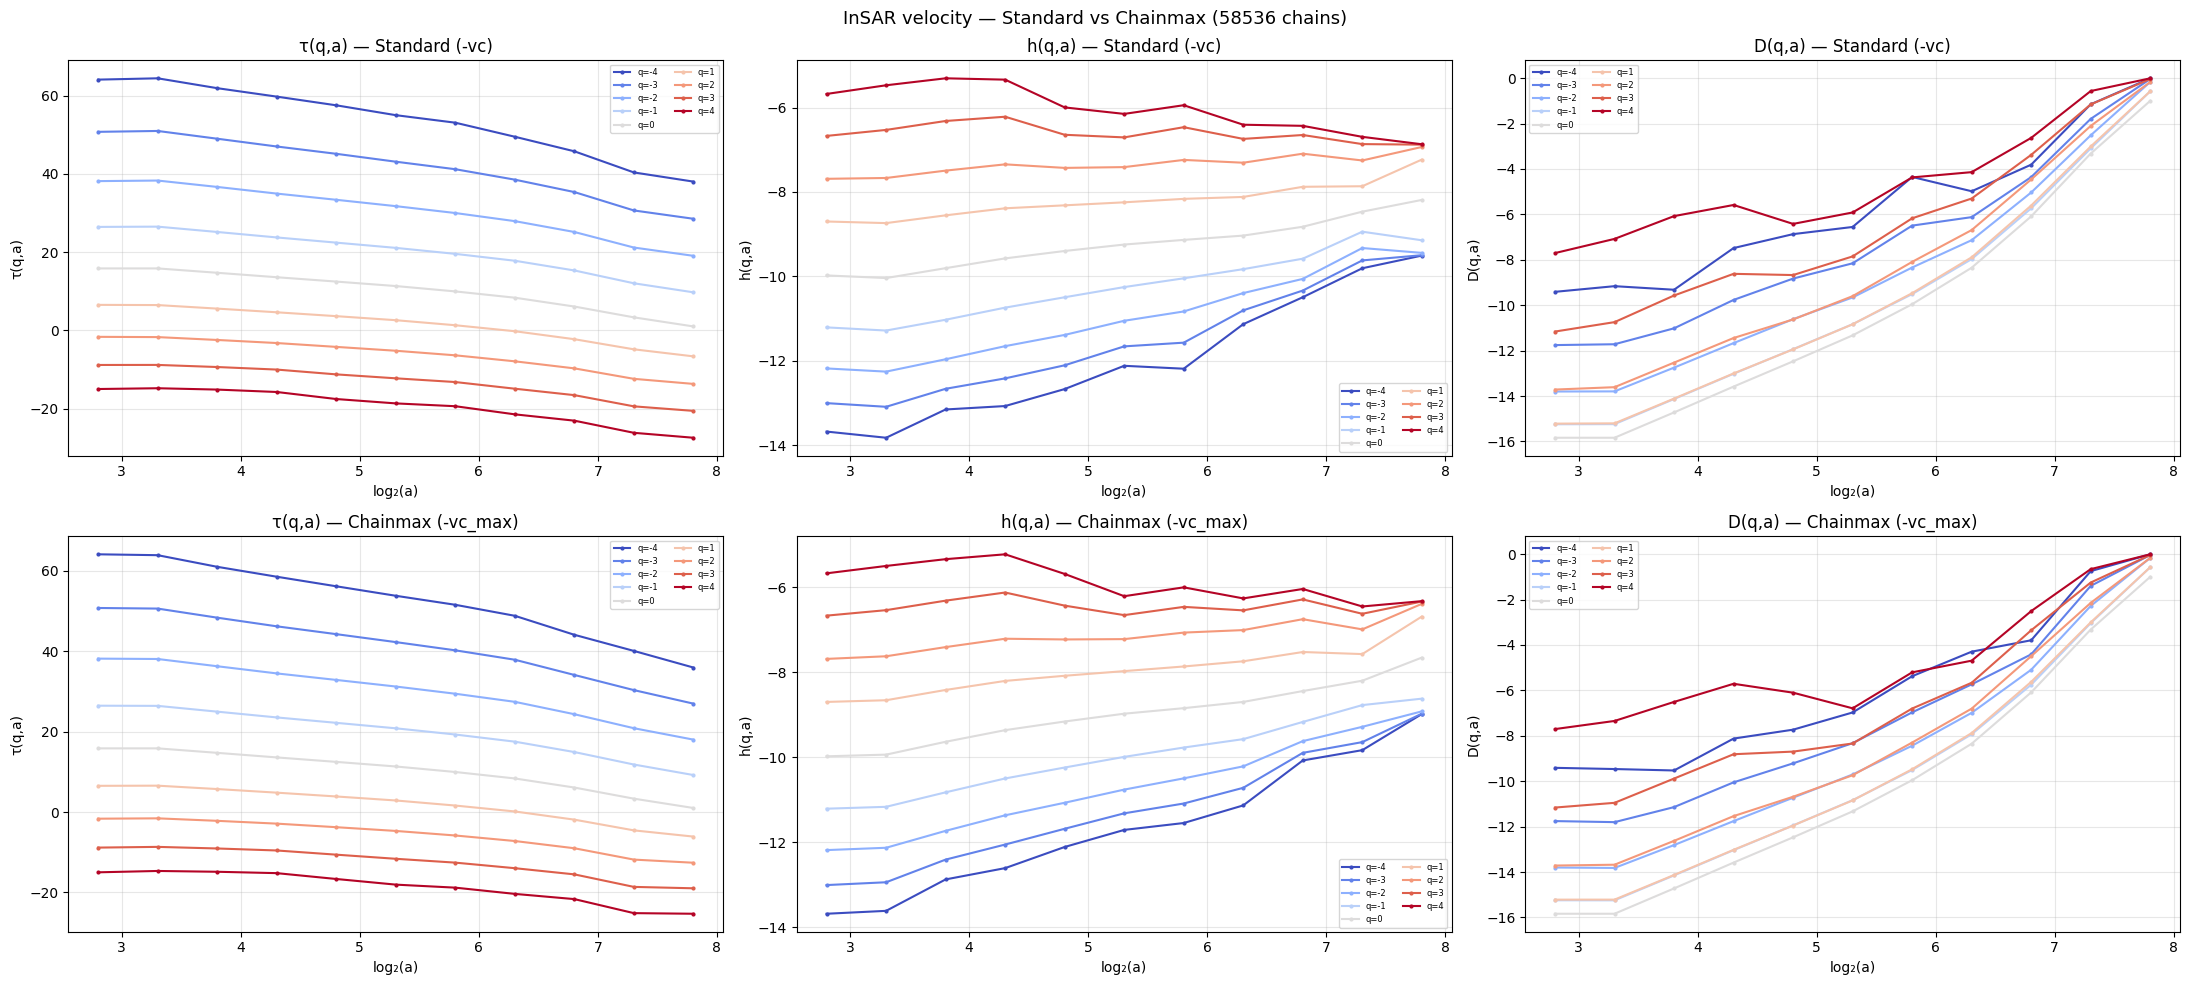

In [ ]:
# Cell 12 - Compute tau(q,a), h(q,a), D(q,a) — BOTH methods: standard and chainmax
import importlib, xsmurf_wrapper.partition
importlib.reload(xsmurf_wrapper.partition)
from xsmurf_wrapper.partition import compute_HD_per_scale, extract_hq_Dq_from_plateaus

q_list = np.concatenate([
    np.arange(-4, -2, .5),
    np.arange(-2, 5.1, 0.1),
    np.arange(2.5, 20, 1)
])

# ---- Method 1: Standard (xsmurf default -vc, no chainmax) ----
n_q = len(q_list)
n_scales_pf = len(scales)
STq = np.zeros((n_q, n_scales_pf), dtype=np.float64)
STqlogT = np.zeros((n_q, n_scales_pf), dtype=np.float64)

# ---- Method 2: Chainmax (-vc_max, sup along chain) ----
# Precompute running max along each filtered chain
chainmax_lookup = [{} for _ in range(n_scales_pf)]
for ch in filtered_chains:
    n_ch = len(ch['mod'])
    running_max = 0.0
    for si in range(min(n_ch, n_scales_pf)):
        m = abs(float(ch['mod'][si]))
        if m > running_max:
            running_max = m
        chainmax_lookup[si][(int(ch['x'][si]), int(ch['y'][si]))] = running_max

STq_sup = np.zeros((n_q, n_scales_pf), dtype=np.float64)
STqlogT_sup = np.zeros((n_q, n_scales_pf), dtype=np.float64)

for j, ext in enumerate(ext_images):
    data = ext.get_extrema_arrays()
    on_vc = ext.get_on_vertical_chain()
    
    mod_list = []
    mod_sup_list = []
    for k in range(ext.extr_nb):
        if on_vc[k]:
            pos_key = (j, int(data['x'][k]), int(data['y'][k]))
            if pos_key in filtered_positions:
                m = abs(float(data['mod'][k]))
                if m > 0:
                    mod_list.append(m)
                    # Chainmax: look up the running max
                    xy_key = (int(data['x'][k]), int(data['y'][k]))
                    m_sup = chainmax_lookup[j].get(xy_key, m)
                    mod_sup_list.append(max(m_sup, 1e-30))
    
    if not mod_list:
        continue
    
    mod = np.array(mod_list, dtype=np.float64)
    mod_sup = np.array(mod_sup_list, dtype=np.float64)
    log_mod = np.log(mod)
    log_mod_sup = np.log(mod_sup)
    
    for i, q in enumerate(q_list):
        # Standard
        mod_q = mod ** q if q != 0 else np.ones(len(mod))
        STq[i, j] = np.sum(mod_q)
        STqlogT[i, j] = np.sum(log_mod * mod_q)
        # Chainmax
        mod_q_sup = mod_sup ** q if q != 0 else np.ones(len(mod_sup))
        STq_sup[i, j] = np.sum(mod_q_sup)
        STqlogT_sup[i, j] = np.sum(log_mod_sup * mod_q_sup)

# Convert both to tau, h, D
log2 = np.log(2.0)

def build_hd(STq_in, STqlogT_in):
    tau_qa = np.full((n_q, n_scales_pf), np.nan)
    h_qa = np.full((n_q, n_scales_pf), np.nan)
    D_qa = np.full((n_q, n_scales_pf), np.nan)
    valid_Z = STq_in > 0
    tau_qa[valid_Z] = np.log(STq_in[valid_Z]) / log2
    h_qa[valid_Z] = STqlogT_in[valid_Z] / (log2 * STq_in[valid_Z])
    for i, q in enumerate(q_list):
        for j_s in range(n_scales_pf):
            if STq_in[i, j_s] > 0:
                D_qa[i, j_s] = (q * STqlogT_in[i, j_s] - STq_in[i, j_s] * np.log(STq_in[i, j_s])) / \
                               (STq_in[i, j_s] * log2)
    return {
        'tau_qa': tau_qa, 'h_qa': h_qa, 'D_qa': D_qa,
        'STq': STq_in, 'STqlogT': STqlogT_in,
        'q_list': np.array(q_list), 'scales': np.array(scales),
        'log2_scales': np.log2(np.array(scales)),
    }

hd = build_hd(STq, STqlogT)
hd_sup = build_hd(STq_sup, STqlogT_sup)

print(f"Partition functions computed with {len(filtered_chains)} filtered chains")
print(f"  Standard: extrema per scale = {[int(STq[n_q//2, j]) for j in range(n_scales_pf)]}")
print(f"  Chainmax: extrema per scale = {[int(STq_sup[n_q//2, j]) for j in range(n_scales_pf)]}")

# Plot both methods side by side
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
q_show = np.arange(-4, 5, 1.0)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

for row, (hd_plot, label) in enumerate([(hd, 'Standard (-vc)'), (hd_sup, 'Chainmax (-vc_max)')]):
    for panel, key, ylabel, title in [
        (0, 'tau_qa', 'τ(q,a)', 'τ(q,a)'),
        (1, 'h_qa', 'h(q,a)', 'h(q,a)'),
        (2, 'D_qa', 'D(q,a)', 'D(q,a)'),
    ]:
        ax = axes[row, panel]
        for qi, color in zip(q_show, colors):
            idx = np.argmin(np.abs(hd_plot['q_list'] - qi))
            y = hd_plot[key][idx]
            v = np.isfinite(y)
            if v.sum() > 1:
                ax.plot(hd_plot['log2_scales'][v], y[v], '.-', color=color,
                        label=f'q={qi:.0f}', ms=4)
        ax.set(xlabel='log₂(a)', ylabel=ylabel, title=f'{title} — {label}')
        ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

plt.suptitle(f'InSAR velocity — Standard vs Chainmax ({len(filtered_chains)} chains)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
%matplotlib widget

from IPython.display import display, clear_output
import ipywidgets as widgets
import numpy as np
import matplotlib.pyplot as plt

fit_state = {'scale_min': 19.0, 'scale_max': 100.0}
log2_s = hd['log2_scales']

naming_toggle = widgets.ToggleButtons(
    options=['multifractal', 'thermodynamic'],
    value='multifractal', description='Labels:')
chainmax_toggle = widgets.ToggleButtons(
    options=['Standard (-vc)', 'Chainmax (-vc_max)'],
    value='Standard (-vc)', description='Method:')

LABELS = {
    'multifractal': {
        'pf': [('tau_qa', 'log₂Z(q,a)', 'τ(q,a)'),
               ('h_qa', 'h(q,a)', 'h(q,a)'),
               ('D_qa', 'D(q,a)', 'D(q,a)')],
        'sp': [('q', 'τ(q)', 'τ(q)'), ('q', 'h(q)', 'h(q)'), ('h', 'D(h)', 'D(h)')],
    },
    'thermodynamic': {
        'pf': [('tau_qa', '-ψ/ln2 = log₂Z(β,a)', 'Helmholtz ψ(β,a)'),
               ('h_qa', 'U(β,a)', 'Internal energy U'),
               ('D_qa', 'G(β,a)', 'Gibbs energy G')],
        'sp': [('β=q', 'ψ(β)=τ(q)', 'Helmholtz ψ'), ('β=q', 'U=h(q)', 'Energy U'), ('U=h', 'S=D(h)', 'Entropy S')],
    },
}

output_pf = widgets.Output()
output_sp = widgets.Output()

q_show = np.array([-4, -3, -2, -1, -0.5, 0, 0.5, 1, 2, 3, 4, 5, 6])
colors_q = plt.cm.coolwarm(np.linspace(0, 1, len(q_show)))

def get_hd():
    return hd if 'Standard' in chainmax_toggle.value else hd_sup

def draw_all():
    smin, smax = fit_state['scale_min'], fit_state['scale_max']
    s_mask = (np.array(scales) >= smin) & (np.array(scales) <= smax)
    hd_cur = get_hd()
    lab = LABELS[naming_toggle.value]
    method = chainmax_toggle.value

    # ---- Top row: partition functions ----
    with output_pf:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        for panel, (key, ylabel, title) in enumerate(lab['pf']):
            ax = axes[panel]
            for qi, color in zip(q_show, colors_q):
                idx = np.argmin(np.abs(hd_cur['q_list'] - qi))
                y = hd_cur[key][idx]
                v = np.isfinite(y)
                if v.sum() < 2:
                    continue
                ax.plot(log2_s[v], y[v], 'o', color=color, ms=3, alpha=0.7, mec='none')

                y_fit = y[s_mask]
                x_fit = log2_s[s_mask]
                v_fit = np.isfinite(y_fit)
                if v_fit.sum() >= 2:
                    try:
                        slope, intercept = np.polyfit(x_fit[v_fit], y_fit[v_fit], 1)
                        x_line = log2_s[v]
                        ax.plot(x_line, slope * x_line + intercept, '-', color=color, lw=1.2, alpha=0.5)
                        ax.text(x_line[-1] + 0.05, slope * x_line[-1] + intercept,
                                f'{qi:g}', color=color, fontsize=7, va='center')
                    except Exception:
                        pass

            ax.axvspan(np.log2(smin), np.log2(smax), alpha=0.15, color='yellow', zorder=0)
            ax.axvline(np.log2(smin), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.axvline(np.log2(smax), color='gray', ls='--', lw=0.8, alpha=0.5)
            ax.set(xlabel='log₂(a)', ylabel=ylabel, title=title)
            ax.grid(True, alpha=0.2)

        fig.suptitle(f'{method} — L-click=min, R-click=max [{smin:.1f}, {smax:.1f}]', fontsize=11)
        fig.tight_layout()

        def on_click(event):
            if event.inaxes is None or event.xdata is None:
                return
            a = 2 ** event.xdata
            if event.button == 1:
                fit_state['scale_min'] = a
            elif event.button == 3:
                fit_state['scale_max'] = a
            if fit_state['scale_min'] > fit_state['scale_max']:
                fit_state['scale_min'], fit_state['scale_max'] = fit_state['scale_max'], fit_state['scale_min']
            draw_all()

        fig.canvas.mpl_connect('button_press_event', on_click)
        plt.show()

    # ---- Bottom row: spectra ----
    if s_mask.sum() < 2:
        return
    res = extract_hq_Dq_from_plateaus(hd_cur, scale_range=(smin, smax))
    q = res['q_list']
    valid = np.isfinite(res['h']) & np.isfinite(res['D']) & np.isfinite(res['tau'])

    with output_sp:
        clear_output(wait=True)
        if not valid.any():
            print("No valid spectra")
            return

        sp = lab['sp']
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Left: tau(q) + h(q) on twin axes
        ax1 = axes[0]
        ax1.errorbar(q[valid], res['tau'][valid], yerr=res['tau_err'][valid],
                     fmt='o-', color='steelblue', ms=4, capsize=2, lw=1.5, label=sp[0][1])
        ax1.set(xlabel=sp[0][0], ylabel=sp[0][1])
        ax1.tick_params(axis='y', labelcolor='steelblue')
        ax1.grid(True, alpha=0.2)

        ax2 = ax1.twinx()
        ax2.errorbar(q[valid], res['h'][valid], yerr=res['h_err'][valid],
                     fmt='s-', color='red', ms=4, capsize=2, lw=1.5, label=sp[1][1])
        ax2.set(ylabel=sp[1][1])
        ax2.tick_params(axis='y', labelcolor='red')
        ax2.axhline(0, color='gray', ls=':', alpha=0.3)

        h_w = res['h'][valid].max() - res['h'][valid].min()
        ax1.set_title(f'{sp[0][2]} & {sp[1][2]} — {method}  Δh={h_w:.3f}')
        lines1, lab1 = ax1.get_legend_handles_labels()
        lines2, lab2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper left', fontsize=8)

        # Right: D(h)
        ax = axes[1]
        sc = ax.scatter(res['h'][valid], res['D'][valid], c=q[valid], cmap='coolwarm',
                        s=60, edgecolors='black', linewidths=0.5, zorder=5)
        ax.errorbar(res['h'][valid], res['D'][valid],
                    xerr=res['h_err'][valid], yerr=res['D_err'][valid],
                    fmt='.', color='gray', ms=1, capsize=1, alpha=0.3)
        plt.colorbar(sc, ax=ax, label='q', shrink=0.7)
        ax.axhline(2, color='gray', ls='--', alpha=0.4, label='d=2')
        pk = np.argmax(res['D'][valid])
        ax.plot(res['h'][valid][pk], res['D'][valid][pk], 'r*', ms=18, zorder=10)
        ax.annotate(f"h*={res['h'][valid][pk]:.3f}\nD*={res['D'][valid][pk]:.3f}",
                    xy=(res['h'][valid][pk], res['D'][valid][pk]),
                    xytext=(res['h'][valid][pk]+0.05, res['D'][valid][pk]-0.15),
                    fontsize=9, arrowprops=dict(arrowstyle='->', color='red'),
                    bbox=dict(boxstyle='round', fc='lightyellow'))
        ax.set(xlabel=sp[2][0], ylabel=sp[2][1], title=f'{sp[2][2]} — {method}')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

        fig.tight_layout()
        plt.show()

def on_toggle(change):
    draw_all()

naming_toggle.observe(on_toggle, names='value')
chainmax_toggle.observe(on_toggle, names='value')

print("LEFT-click = min scale | RIGHT-click = max scale")
display(widgets.HBox([naming_toggle, chainmax_toggle]))
display(output_pf)
display(output_sp)
draw_all()


LEFT-click = min scale | RIGHT-click = max scale


Output()

Output()

In [33]:
# 3D WTMM Skeleton — horizontal chains at each scale level, vertical chains connecting them
import pyvista as pv
from ipywidgets import interact, IntSlider, Checkbox, FloatSlider, Layout
import numpy as np

pv.set_jupyter_backend('trame')

# Downsample factor for the base image texture
ds_tex = max(1, max(crop_image.shape) // 512)

# Build 3D skeleton data
log2_scales_arr = np.log2(scales)

# --- Horizontal chain lines (per scale) ---
h_lines_points = []
h_lines_cells = []
h_lines_scalars = []  # modulus for coloring
pt_offset = 0

for si in range(len(scales)):
    ext = ext_images[si]
    lines = ext.get_lines()
    lx_ext = ext.lx
    z_val = float(si) * crop_image.shape[1] / len(scales)  # scale like xsmurf: lx * index / n_scales
    
    for line in lines:
        if line['size'] < 5:  # skip very short chains
            continue
        positions = line['extrema_pos']
        xs = np.array([int(p) % lx_ext for p in positions], dtype=np.float32)
        ys = np.array([int(p) // lx_ext for p in positions], dtype=np.float32)
        n = len(xs)
        
        pts = np.column_stack([xs, ys, np.full(n, z_val)])
        h_lines_points.append(pts)
        
        # Build polyline cell: [n, idx0, idx1, ..., idx_{n-1}]
        cell = np.zeros(n + 1, dtype=np.int64)
        cell[0] = n
        cell[1:] = np.arange(pt_offset, pt_offset + n)
        h_lines_cells.append(cell)
        
        mods = np.array([line['extrema_mod'][j] if j < len(line['extrema_mod']) else 0 
                         for j in range(n)], dtype=np.float32)
        h_lines_scalars.append(mods)
        pt_offset += n

if h_lines_points:
    all_h_pts = np.vstack(h_lines_points)
    all_h_cells = np.concatenate(h_lines_cells)
    all_h_scalars = np.concatenate(h_lines_scalars)
    h_mesh = pv.PolyData(all_h_pts, lines=all_h_cells)
    h_mesh['modulus'] = all_h_scalars
    print(f"Horizontal chains: {len(h_lines_points)} lines, {len(all_h_pts)} points")
else:
    h_mesh = None
    print("No horizontal chains")

# --- Vertical chain lines ---
v_lines_points = []
v_lines_cells = []
v_lines_h = []  # holder exponent for coloring
pt_offset_v = 0

for ch in chains:
    n = len(ch['mod'])
    if n < 2:
        continue
    xs = ch['x'].astype(np.float32)
    ys = ch['y'].astype(np.float32)
    zs = (np.arange(n, dtype=np.float32) * crop_image.shape[1] / len(scales))  # match h-chain Z
    
    pts = np.column_stack([xs, ys, zs])
    v_lines_points.append(pts)
    
    cell = np.zeros(n + 1, dtype=np.int64)
    cell[0] = n
    cell[1:] = np.arange(pt_offset_v, pt_offset_v + n)
    v_lines_cells.append(cell)
    
    key = (int(ch['x'][0]), int(ch['y'][0]))
    h_val = h_slope_lookup.get(key, np.nan)
    v_lines_h.append(np.full(n, h_val, dtype=np.float32))
    pt_offset_v += n

if v_lines_points:
    all_v_pts = np.vstack(v_lines_points)
    all_v_cells = np.concatenate(v_lines_cells)
    all_v_h = np.concatenate(v_lines_h)
    v_mesh = pv.PolyData(all_v_pts, lines=all_v_cells)
    v_mesh['h'] = all_v_h
    print(f"Vertical chains: {len(v_lines_points)} lines, {len(all_v_pts)} points")
else:
    v_mesh = None
    print("No vertical chains")

# --- Base image as textured plane ---
base_img = crop_image[::ds_tex, ::ds_tex]
ny_b, nx_b = base_img.shape
plane = pv.Plane(center=(nx_b*ds_tex/2, ny_b*ds_tex/2, -crop_image.shape[1] / len(scales)),
                 direction=(0, 0, 1),
                 i_size=nx_b*ds_tex, j_size=ny_b*ds_tex,
                 i_resolution=1, j_resolution=1)

print("\n3D skeleton data ready. Rendering...")

# --- Render ---
pl = pv.Plotter()

# Base image
tex = pv.numpy_to_texture(np.flipud(
    plt.cm.gray((base_img - base_img.min()) / (base_img.max() - base_img.min() + 1e-10))[:, :, :3]
).astype(np.uint8) if False else
    (plt.cm.gray((base_img - base_img.min()) / max(base_img.max() - base_img.min(), 1e-10))[:, :, :3] * 255).astype(np.uint8)
)
pl.add_mesh(plane, texture=tex, opacity=0.5)

# Horizontal chains
if h_mesh is not None:
    pl.add_mesh(h_mesh, scalars='modulus', cmap='hot', line_width=1,
                opacity=0.4, label='H-chains')

# Vertical chains
if v_mesh is not None:
    valid_h = all_v_h[~np.isnan(all_v_h)]
    if len(valid_h) > 0:
        clim = [np.percentile(valid_h, 5), np.percentile(valid_h, 95)]
    else:
        clim = [-1, 1]
    pl.add_mesh(v_mesh, scalars='h', cmap='RdBu_r', line_width=2,
                clim=clim, opacity=0.8, label='V-chains (h)')

pl.add_axes(xlabel='X (pixels)', ylabel='Y (pixels)', zlabel='scale (voice index)')
pl.set_background('white')
pl.camera.elevation = -30
pl.camera.azimuth = 45
pl.show()


Horizontal chains: 183040 lines, 4446721 points
Vertical chains: 62497 lines, 270604 points

3D skeleton data ready. Rendering...


Widget(value='<iframe src="http://localhost:52741/index.html?ui=P_0x58293cc80_1&reconnect=auto" class="pyvista…